# RQ1: To what extent can expected flight delays be modeled using historical flight operation patterns while staying useful for passenger or airline scheduling decisions?

## Motivation

As opposed to only focusing on predicting delays as accurately as possible, the updated RQ1 shifts to testing the extent to which expected delays can be modeled using historical operational and scheduling data, and whether the predictions we make could hypothetically be useful for real passenger or airline scheduling decisions. This change was made to add some depth to the question by adding more of an applied goal to it. In particular, we will also now evaluate our model’s performance in terms of practical usefulness for passengers and airlines, rather than only statistical accuracy.

Our use of operational data in prediction reflects the information that is most available to airport planners who make flight scheduling decisions. For example, we use measures such as airport traffic frequency and historical average delay measures, because they represent information that airlines and airports already track as part of their scheduling and planning processes. By using operational data that is commonly available in practice, we can better evaluate whether prediction models similar to ours would realistically be useful for airport planners to use in real scheduling.

RQ1 focuses on a comparison of two versions of the same prediction pipeline. The first is an advance data only model that uses scheduled timing, route, airport, airline, and historical operational trend variables. The second is a taxi extended model that adds TaxiIn and TaxiOut, which provide more immediate operational information on the day of departure, which would not realistically be available far in advance. Instead of evaluating the models only by mean absolute error, we also test whether flights flagged as highest risk by the models actually experience meaningfully worse delays in reality. This allows us to assess whether the models are useful for risk classification, even if precise delay duration prediction remains difficult using only historical operational and scheduling data.

## Proposed Methodology 

To answer RQ1, we built two versions of a flight delay prediction pipeline and evaluated each using a baseline linear regression and a dense neural network, using the U.S domestic flight dataset from 2018 to 2022. For faster computation, the current settings on the models use a 10\% stratified sample by year, which keeps the multi-year structure of the data while shortening runtime. From the parquet files available in our dataset, we use features related to schedule timing, airline and route information, airport and regional information, flight distance, and elapsed time to predict departure delay as our target. We also included TaxiIn and TaxiOut in the short-term data version of the model. TaxiOut measures the time from gate departure to takeoff, while TaxiIn measures the time from landing to gate arrival. These variables provide more immediate operational information, but they are also not realistically available at least a day in advance. The additional short term model specification is created to compare how prediction accuracy improves using data recorded on the day of the flight. Unfortunately, some of the most potentially useful short-term features, such as CarrierDelay, WeatherDelay, NASDelay, SecurityDelay, and LateAircraftDelay were not actually present in the downloadable parquet files, so these features were not able to be added to the short-term model.

The data was first cleaned by removing duplicate columns, encoding categorical variables to integer codes, and casting numerical variables into more memory efficient data types. We then engineered several time features, those being departure hour, arrival hour, week of year, and day of year. We also built a route identifier from the origin and destination airports, so that the historical route specific delay characteristics could be picked up in the models.

For our test-train split, the dataset was split by years, with the flight data from 2018 to 2021 used for training and the 2022 data used for testing. This time based split is more useful than a random split because it uses historical patterns to make predictions on a future year, as would be done in practice. After train and test were split, we removed extreme departure delay outliers outside the 1st and 99th percentiles based on the training set only, and then applied those same bounds to both the training and test sets in order to reduce their influence on the models. We also made several historical encodings for the training set, which include origin and destination traffic frequency, average departure delay by origin airport, average arrival delay by destination airport, average departure delay by operating airline, average arrival delay by route, and average departure delay by aircraft tail number. These were computed from the training period but then mapped onto both the training and test sets, so the model could capture operation patterns without using the future target information to avoid data leakage.

To serve as a benchmark against our two dense neural network specifications, we first ran two baseline linear regression models using SGDRegressor with L2 regularization and standardized inputs. Then we ran our dense neural network (DNN) models, which both have two hidden layers of 128 and 64 neurons and ReLU activation functions. The networks were trained using the Adam optimizer and an L1 loss objective, over 20 epochs with a batch size of 4096. The inputs were standardized separately for each model specification before training both the regression and DNN models. Both the regression and DNN were trained and tested on the advance data only specification with 27 features, as well as the taxi extended feature set with 29 features.

The first performance evaluation metric we used on our models was Mean Absolute Error (MAE), which measures the average difference between predicted and actual departure delay in minutes. Second, because accurate departure delay prediction proved to be difficult using our highly skewed historical delay data, we also tested the models as risk of delay assessment tools. For the dense neural network, flights were ranked by their predicted departure delays and then were grouped into top 25\%, top 15\%, and top 5\% predicted delay subsets. For each subset, we measured the realized mean delay and the share of the flights that were delayed by at least 15 minutes. This allows us to test whether the flights with the longest predicted delays actually corresponded to significantly longer delays in reality, essentially testing if our model is able to identify flights at the highest risk of a long delay.

## Library Imports

In [1]:
#Import libraries for data handling, modeling, and visualization
import pandas as pd
import numpy as np
from tqdm import tqdm
from glob import glob
import matplotlib.pyplot as plt

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from scipy.stats import gaussian_kde

## Data Loading and Sample Settings

In [2]:
#Load selected parquet files and optionally apply stratified sampling for faster experimentation
files = glob("../data/flight-delay-dataset-20182022/Combined_Flights_*.parquet")

columns = [
    "FlightDate",
    "Year",
    "Quarter",
    "Month",
    "DayofMonth",
    "DayOfWeek",
    "CRSDepTime",
    "CRSArrTime",
    "DepTimeBlk",
    "ArrTimeBlk",
    "Operating_Airline",
    "OriginAirportID",
    "DestAirportID",
    "OriginCityMarketID",
    "DestCityMarketID",
    "Distance",
    "DistanceGroup",
    "Marketing_Airline_Network",
    "DOT_ID_Operating_Airline",
    "Tail_Number",
    "Flight_Number_Operating_Airline",
    "DepDelay",
    "ArrDelay",
    "OriginState",
    "DestState",
    "OriginWac",
    "DestWac",
    "CRSElapsedTime",
    "TaxiOut",
    "TaxiIn"
]

df = pd.read_parquet(files, columns=columns, engine="pyarrow")

# Can adjust stratified sample size for faster computation time
DEBUG = True
#Currently using 0.10 fraction
DEBUG_FRAC = 0.10

if DEBUG:
    df = (
        df.groupby("Year", group_keys=False)
        .apply(lambda x: x.sample(frac=DEBUG_FRAC, random_state=42))
        .reset_index(drop=True)
    )

print(f"Debug mode ON: using {len(df):,} rows")

C:\Users\brian\AppData\Local\Temp\ipykernel_35716\690974219.py:47: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=DEBUG_FRAC, random_state=42))


Debug mode ON: using 2,919,378 rows


## Data Exploration

In [3]:
import pyarrow.parquet as pq

parquet_cols = pq.ParquetFile(files[0]).schema.names

print("Number of columns in parquet file:", len(parquet_cols))
print(parquet_cols)

df.info()

df.nunique()

Number of columns in parquet file: 62
['FlightDate', 'Airline', 'Origin', 'Dest', 'Cancelled', 'Diverted', 'CRSDepTime', 'DepTime', 'DepDelayMinutes', 'DepDelay', 'ArrTime', 'ArrDelayMinutes', 'AirTime', 'CRSElapsedTime', 'ActualElapsedTime', 'Distance', 'Year', 'Quarter', 'Month', 'DayofMonth', 'DayOfWeek', 'Marketing_Airline_Network', 'Operated_or_Branded_Code_Share_Partners', 'DOT_ID_Marketing_Airline', 'IATA_Code_Marketing_Airline', 'Flight_Number_Marketing_Airline', 'Operating_Airline', 'DOT_ID_Operating_Airline', 'IATA_Code_Operating_Airline', 'Tail_Number', 'Flight_Number_Operating_Airline', 'OriginAirportID', 'OriginAirportSeqID', 'OriginCityMarketID', 'OriginCityName', 'OriginState', 'OriginStateFips', 'OriginStateName', 'OriginWac', 'DestAirportID', 'DestAirportSeqID', 'DestCityMarketID', 'DestCityName', 'DestState', 'DestStateFips', 'DestStateName', 'DestWac', 'DepDel15', 'DepartureDelayGroups', 'DepTimeBlk', 'TaxiOut', 'WheelsOff', 'WheelsOn', 'TaxiIn', 'CRSArrTime', 'ArrDe

FlightDate                         1673
Year                                  5
Quarter                               4
Month                                12
DayofMonth                           31
DayOfWeek                             7
CRSDepTime                         1394
CRSArrTime                         1438
DepTimeBlk                           19
ArrTimeBlk                           19
Operating_Airline                    28
OriginAirportID                     387
DestAirportID                       387
OriginCityMarketID                  361
DestCityMarketID                    361
Distance                           1725
DistanceGroup                        11
Marketing_Airline_Network            11
DOT_ID_Operating_Airline             28
Tail_Number                        7056
Flight_Number_Operating_Airline    7193
DepDelay                           1453
ArrDelay                           1481
OriginState                          53
DestState                            53


## Data Preprocessing and Variable Encoding

In [4]:
# Preprocessing steps: encode categoricals, convert dtypes, create time features, and build route identifiers
#1. Remove duplicated columns
df = df.loc[:, ~df.columns.duplicated()]

#2. Extract useful time features
df["dep_hour"] = df["CRSDepTime"] // 100
df["arr_hour"] = df["CRSArrTime"] // 100

df["week_of_year"] = df["FlightDate"].dt.isocalendar().week.astype("int16")
df["day_of_year"] = df["FlightDate"].dt.dayofyear.astype("int16")

#3. Convert string categoricals to integer codes
cat_cols = [
    "Operating_Airline",
    "Marketing_Airline_Network",
    "DepTimeBlk",
    "ArrTimeBlk",
    "Tail_Number",
    "OriginState",
    "DestState"
]

for col in cat_cols:
    df[col] = df[col].astype("category").cat.codes.astype("int32")

#4. Numeric type conversions 
df["Distance"] = df["Distance"].astype("float32")
df["DistanceGroup"] = df["DistanceGroup"].astype("int8")

df["OriginAirportID"] = df["OriginAirportID"].astype("int32")
df["DestAirportID"] = df["DestAirportID"].astype("int32")

df["OriginCityMarketID"] = df["OriginCityMarketID"].astype("int32")
df["DestCityMarketID"] = df["DestCityMarketID"].astype("int32")

df["DOT_ID_Operating_Airline"] = df["DOT_ID_Operating_Airline"].astype("int32")
df["Flight_Number_Operating_Airline"] = df["Flight_Number_Operating_Airline"].astype("int32")

df["OriginWac"] = df["OriginWac"].astype("int16")
df["DestWac"] = df["DestWac"].astype("int16")
df["CRSElapsedTime"] = df["CRSElapsedTime"].astype("float32")

df["TaxiOut"] = df["TaxiOut"].astype("float32")
df["TaxiIn"] = df["TaxiIn"].astype("float32")

#5. Route feature 
df["route_id"] = (
    df["OriginAirportID"].astype("int64") * 100000 +
    df["DestAirportID"].astype("int64")
).astype("int64")

#6. Drop raw date, then remove missing
df = df.drop(columns=["FlightDate"])
df = df.dropna()

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 2834058 entries, 0 to 2919376
Data columns (total 34 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Year                             int64  
 1   Quarter                          int64  
 2   Month                            int64  
 3   DayofMonth                       int64  
 4   DayOfWeek                        int64  
 5   CRSDepTime                       int64  
 6   CRSArrTime                       int64  
 7   DepTimeBlk                       int32  
 8   ArrTimeBlk                       int32  
 9   Operating_Airline                int32  
 10  OriginAirportID                  int32  
 11  DestAirportID                    int32  
 12  OriginCityMarketID               int32  
 13  DestCityMarketID                 int32  
 14  Distance                         float32
 15  DistanceGroup                    int8   
 16  Marketing_Airline_Network        int32  
 17  DOT_ID_Operat

## Train Test Split

Train outlier bounds: -15.0 183.0
Train shape after outlier filter: (2396654, 34)
Test shape after outlier filter: (388229, 34)
Train shape: (2396654, 37)
Test shape: (388229, 37)


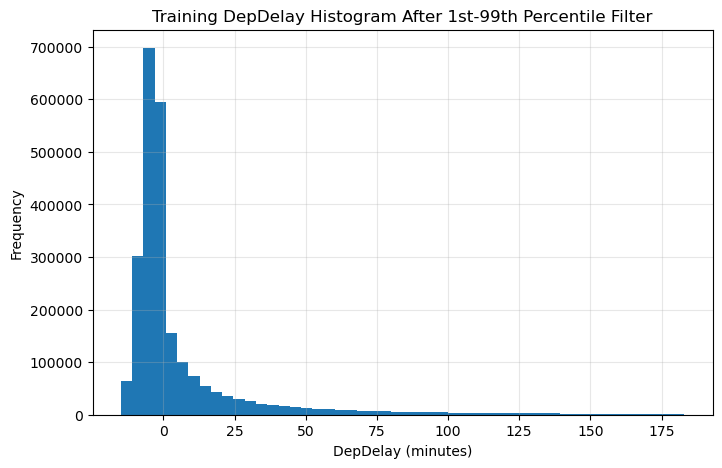

In [5]:
#Create time-based train/test split and build historical encodings using Train only to avoid leakage

#Train-test split
train = df[df["Year"] <= 2021].copy()
test = df[df["Year"] == 2022].copy()

#Outlier filtering based on train only
lower = train["DepDelay"].quantile(0.01)
upper = train["DepDelay"].quantile(0.99)

train = train[(train["DepDelay"] >= lower) & (train["DepDelay"] <= upper)].copy()
test = test[(test["DepDelay"] >= lower) & (test["DepDelay"] <= upper)].copy()

print("Train outlier bounds:", lower, upper)
print("Train shape after outlier filter:", train.shape)
print("Test shape after outlier filter:", test.shape)

#Build historical / frequency features using train only

# Frequency and historical average encodings are learned from the training period only and then mapped onto both train and test to avoid target leakage.
#Frequency encoding
origin_freq_map = train["OriginAirportID"].value_counts()
dest_freq_map = train["DestAirportID"].value_counts()

train["origin_freq"] = train["OriginAirportID"].map(origin_freq_map).astype("float32")
train["dest_freq"] = train["DestAirportID"].map(dest_freq_map).astype("float32")

test["origin_freq"] = test["OriginAirportID"].map(origin_freq_map).astype("float32")
test["dest_freq"] = test["DestAirportID"].map(dest_freq_map).astype("float32")

#Historical average delay encodings
origin_dep_delay_map = train.groupby("OriginAirportID")["DepDelay"].mean()
dest_arr_delay_map = train.groupby("DestAirportID")["ArrDelay"].mean()
airline_delay_map = train.groupby("Operating_Airline")["DepDelay"].mean()
route_delay_map = train.groupby("route_id")["ArrDelay"].mean()
tail_delay_map = train.groupby("Tail_Number")["DepDelay"].mean()

train["origin_avg_dep_delay"] = train["OriginAirportID"].map(origin_dep_delay_map).astype("float32")
train["dest_avg_arr_delay"] = train["DestAirportID"].map(dest_arr_delay_map).astype("float32")
train["airline_avg_delay"] = train["Operating_Airline"].map(airline_delay_map).astype("float32")
train["route_avg_delay"] = train["route_id"].map(route_delay_map).astype("float32")
train["tail_avg_delay"] = train["Tail_Number"].map(tail_delay_map).astype("float32")

test["origin_avg_dep_delay"] = test["OriginAirportID"].map(origin_dep_delay_map).astype("float32")
test["dest_avg_arr_delay"] = test["DestAirportID"].map(dest_arr_delay_map).astype("float32")
test["airline_avg_delay"] = test["Operating_Airline"].map(airline_delay_map).astype("float32")
test["route_avg_delay"] = test["route_id"].map(route_delay_map).astype("float32")
test["tail_avg_delay"] = test["Tail_Number"].map(tail_delay_map).astype("float32")

#Fill unseen values in test with train-based fallbacks
fallbacks = {
    "origin_freq": train["origin_freq"].median(),
    "dest_freq": train["dest_freq"].median(),
    "origin_avg_dep_delay": train["origin_avg_dep_delay"].mean(),
    "dest_avg_arr_delay": train["dest_avg_arr_delay"].mean(),
    "airline_avg_delay": train["airline_avg_delay"].mean(),
    "route_avg_delay": train["route_avg_delay"].mean(),
    "tail_avg_delay": train["tail_avg_delay"].mean(),
}

for col, val in fallbacks.items():
    train[col] = train[col].fillna(val)
    test[col] = test[col].fillna(val)

#Drop raw IDs used only for encoding
drop_cols = [
    "OriginAirportID",
    "DestAirportID",
    "route_id",
    "Tail_Number"
]

train = train.drop(columns=drop_cols)
test = test.drop(columns=drop_cols)

train = train.fillna(0)
test = test.fillna(0)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

plt.figure(figsize=(8, 5))
plt.hist(train["DepDelay"], bins=50)
plt.xlabel("DepDelay (minutes)")
plt.ylabel("Frequency")
plt.title("Training DepDelay Histogram After 1st-99th Percentile Filter")
plt.grid(alpha=0.3)
plt.show()

## Feature Sets

In [6]:
#Define two RQ1 feature sets: advance only and taxi included


#Advance only features are data that is available well before departure.
advance_features = [
    "Quarter", "Month", "DayofMonth", "DayOfWeek",
    "dep_hour", "arr_hour", "week_of_year", "day_of_year",
    "Distance", "DistanceGroup", "CRSElapsedTime",
    "OriginWac", "DestWac",
    "Operating_Airline", "Marketing_Airline_Network",
    "Flight_Number_Operating_Airline",
    "DepTimeBlk", "ArrTimeBlk",
    "OriginState", "DestState",
    "origin_freq", "dest_freq",
    "origin_avg_dep_delay", "dest_avg_arr_delay",
    "airline_avg_delay", "route_avg_delay", "tail_avg_delay"
]

#Taxi extended features add short-horizon operational information.
taxi_features = advance_features + [
    "TaxiOut",
    "TaxiIn"
]

print("Advance feature count:", len(advance_features))
print("Taxi-extended feature count:", len(taxi_features))

Advance feature count: 27
Taxi-extended feature count: 29


## Regression Baseline

In [7]:
#Train and evaluate linear regression baselines for both feature sets

from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

y_train = train["DepDelay"]
y_test = test["DepDelay"]

regression_results = []

for label, features in [
    ("Advance Only", advance_features),
    ("Advance + Taxi", taxi_features),
]:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train[features])
    X_test = scaler.transform(test[features])

    model = SGDRegressor(
        loss="squared_error",
        penalty="l2",
        alpha=0.0001,
        max_iter=1000,
        learning_rate="adaptive"
    )

    model.fit(X_train, y_train)
    pred_reg = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred_reg)

    regression_results.append({
        "model_version": label,
        "mae": mae
    })

    print(f"{label} Regression MAE: {mae}")

Advance Only Regression MAE: 15.897253945433539
Advance + Taxi Regression MAE: 15.87859018239425


## Dense-NN

In [8]:
#Train and evaluate dense neural networks for both feature sets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

class DelayModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)


#Function to train a dense neural network and return predictions, loss history, and MAE
def run_nn_version(features, label, epochs=20, batch_size=4096):
    y_train_np = train["DepDelay"].values.astype(np.float32)
    y_test_np = test["DepDelay"].values.astype(np.float32)

    #Standardize inputs separately for each model specification
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train[features])
    X_test = scaler.transform(test[features])

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1)

    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = DelayModel(len(features)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.L1Loss()

    losses = []

    for epoch in range(epochs):
        total_loss = 0.0
        for xb, yb in loader:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            pred_batch = model(xb)
            loss = loss_fn(pred_batch, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)
        print(f"{label} | epoch {epoch+1}/{epochs} loss: {total_loss:.4f}")

    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

    with torch.no_grad():
        pred = model(X_test_t).cpu().numpy().flatten()

    mae = mean_absolute_error(y_test_np, pred)
    print(f"{label} NN MAE: {mae}")

    result_df = pd.DataFrame({
        "pred_delay": pred,
        "actual_delay": y_test_np
    })

    return {
        "label": label,
        "mae": mae,
        "losses": losses,
        "pred_df": result_df
    }

Using device: cpu


## Comparing DNN Models Results

Advance Only | epoch 1/20 loss: 6947.7864
Advance Only | epoch 2/20 loss: 6899.6854
Advance Only | epoch 3/20 loss: 6877.9718
Advance Only | epoch 4/20 loss: 6866.0506
Advance Only | epoch 5/20 loss: 6861.7204
Advance Only | epoch 6/20 loss: 6860.2384
Advance Only | epoch 7/20 loss: 6853.1913
Advance Only | epoch 8/20 loss: 6851.6394
Advance Only | epoch 9/20 loss: 6850.2171
Advance Only | epoch 10/20 loss: 6848.5990
Advance Only | epoch 11/20 loss: 6844.8295
Advance Only | epoch 12/20 loss: 6846.6822
Advance Only | epoch 13/20 loss: 6843.0806
Advance Only | epoch 14/20 loss: 6839.8983
Advance Only | epoch 15/20 loss: 6840.8887
Advance Only | epoch 16/20 loss: 6837.9688
Advance Only | epoch 17/20 loss: 6837.2984
Advance Only | epoch 18/20 loss: 6836.9836
Advance Only | epoch 19/20 loss: 6833.5546
Advance Only | epoch 20/20 loss: 6833.2246
Advance Only NN MAE: 14.305978775024414
Advance + Taxi | epoch 1/20 loss: 6932.1609
Advance + Taxi | epoch 2/20 loss: 6879.7952
Advance + Taxi | epoc

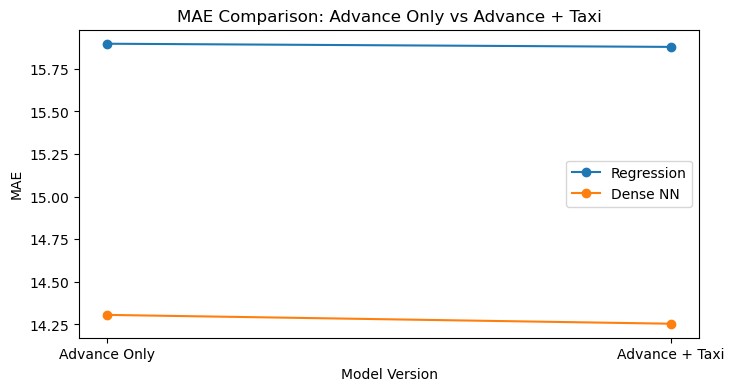

In [9]:
#Compare model accuracy across advance data only and taxi extended specifications

advance_nn_result = run_nn_version(
    features=advance_features,
    label="Advance Only",
    epochs=20,
    batch_size=4096
)

taxi_nn_result = run_nn_version(
    features=taxi_features,
    label="Advance + Taxi",
    epochs=20,
    batch_size=4096
)

print("Advance Only NN MAE:", advance_nn_result["mae"])
print("Advance + Taxi NN MAE:", taxi_nn_result["mae"])

#Compare MAE directly
mae_compare_df = pd.DataFrame([
    {"Model": "Regression", "Version": "Advance Only", "MAE": regression_results[0]["mae"]},
    {"Model": "Regression", "Version": "Advance + Taxi", "MAE": regression_results[1]["mae"]},
    {"Model": "Dense NN", "Version": "Advance Only", "MAE": advance_nn_result["mae"]},
    {"Model": "Dense NN", "Version": "Advance + Taxi", "MAE": taxi_nn_result["mae"]},
])

print(mae_compare_df)

plt.figure(figsize=(8, 4))
for model_name in mae_compare_df["Model"].unique():
    subset = mae_compare_df[mae_compare_df["Model"] == model_name]
    plt.plot(subset["Version"], subset["MAE"], marker="o", label=model_name)

plt.title("MAE Comparison: Advance Only vs Advance + Taxi")
plt.ylabel("MAE")
plt.xlabel("Model Version")
plt.legend()

## Prediction Distribution Graph

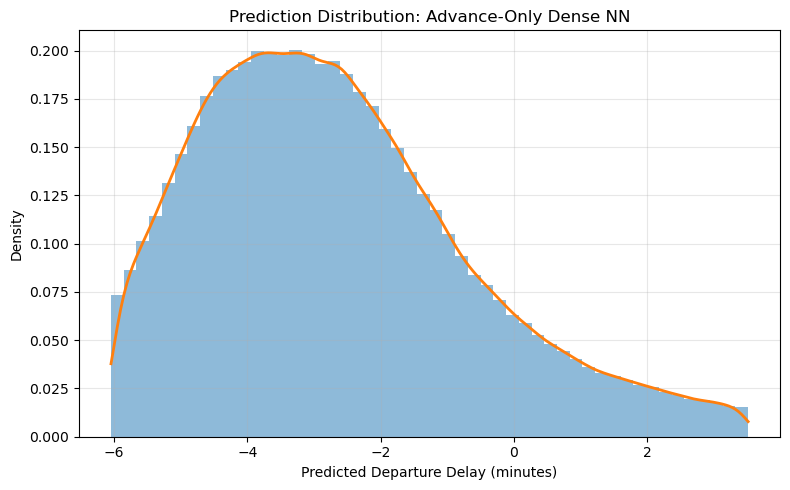

In [10]:
#Visualizes the prediction distribution of the advance data only dense neural network 

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

preds_np = advance_nn_result["pred_df"]["pred_delay"].values

percentile_band = 0.05
lower = np.quantile(preds_np, percentile_band)
upper = np.quantile(preds_np, 1.0 - percentile_band)

preds_filtered = preds_np[(preds_np >= lower) & (preds_np <= upper)]

plt.figure(figsize=(8, 5))
plt.hist(preds_filtered, bins=50, density=True, alpha=0.5)

kde = gaussian_kde(preds_filtered)
x = np.linspace(preds_filtered.min(), preds_filtered.max(), 200)
plt.plot(x, kde(x), linewidth=2)

plt.title("Prediction Distribution: Advance-Only Dense NN")
plt.xlabel("Predicted Departure Delay (minutes)")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## High Delay Risk Flight Identification

In [11]:
#Summarize high risk flight prediction performance at different prediction cutoffs

def summarize_top_risk(df, top_frac):
    out = df.copy()
    out["actual_delay_positive"] = (out["actual_delay"] > 0).astype(int)
    out["actual_delay_15plus"] = (out["actual_delay"] >= 15).astype(int)

    threshold = out["pred_delay"].quantile(1 - top_frac)

    out["risk_group"] = np.where(
        out["pred_delay"] >= threshold,
        f"Top {int(top_frac*100)}% Risk",
        f"Bottom {int((1-top_frac)*100)}%"
    )

    summary = out.groupby("risk_group").agg(
        flights=("actual_delay", "size"),
        mean_pred_delay=("pred_delay", "mean"),
        mean_actual_delay=("actual_delay", "mean"),
        median_actual_delay=("actual_delay", "median"),
        pct_delayed_gt_0=("actual_delay_positive", "mean"),
        pct_delayed_15plus=("actual_delay_15plus", "mean")
    ).reset_index()

    summary["pct_delayed_gt_0"] *= 100
    summary["pct_delayed_15plus"] *= 100

    return threshold, summary

for label, result in [
    ("Advance Only", advance_nn_result),
    ("Advance + Taxi", taxi_nn_result)
]:
    print(f"\n================ {label} ================\n")
    for frac in [0.25, 0.15, 0.05]:
        threshold, summary = summarize_top_risk(result["pred_df"], frac)
        print(f"===== Top {int(frac*100)}% Risk Cutoff =====")
        print("Prediction threshold:", threshold)
        print(summary)


================ Advance Only ================

===== Top 25% Risk Cutoff =====
Prediction threshold: -1.2495542764663696
     risk_group  flights  mean_pred_delay  mean_actual_delay  \
0    Bottom 75%   291171        -3.728978           6.263931   
1  Top 25% Risk    97058         2.046413          17.348173   

   median_actual_delay  pct_delayed_gt_0  pct_delayed_15plus  
0                 -3.0         31.789910           16.441541  
1                  4.0         59.426322           34.211502  
===== Top 15% Risk Cutoff =====
Prediction threshold: 0.005593551695345977
     risk_group  flights  mean_pred_delay  mean_actual_delay  \
0    Bottom 85%   329994        -3.371392           6.968754   
1  Top 15% Risk    58235         3.870343          20.743660   

   median_actual_delay  pct_delayed_gt_0  pct_delayed_15plus  
0                 -2.0         33.879101           17.511531  
1                  8.0         66.011849           39.994848  
===== Top 5% Risk Cutoff =====
Predict

## Evaluation of Top 25%, 15%, and 5% Delay Risk Flights

          Version   Cutoff  Mean Actual Delay  15+ Min Delay Rate
0    Advance Only  Top 25%          17.348173           34.211502
1    Advance Only  Top 15%          20.743660           39.994848
2    Advance Only   Top 5%          25.903616           48.804863
3  Advance + Taxi  Top 25%          18.119280           35.246966
4  Advance + Taxi  Top 15%          21.741890           41.322229
5  Advance + Taxi   Top 5%          27.298218           49.732124


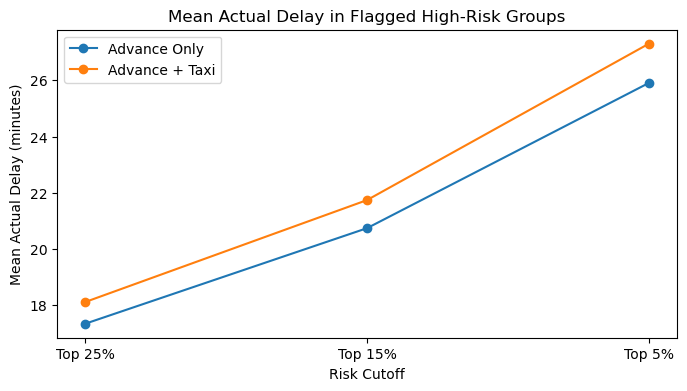

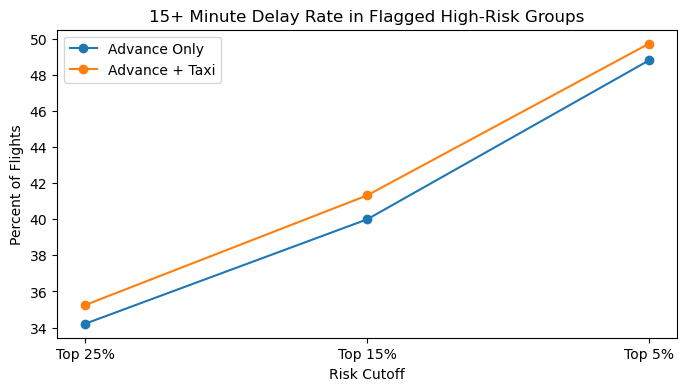

In [12]:
#Evaluate whether the highest predicted risk flights experience worse actual delays
cutoffs = [0.25, 0.15, 0.05]
rows = []

for label, result in [
    ("Advance Only", advance_nn_result),
    ("Advance + Taxi", taxi_nn_result)
]:
    for frac in cutoffs:
        threshold, summary = summarize_top_risk(result["pred_df"], frac)

        top_label = f"Top {int(frac*100)}% Risk"
        top_row = summary[summary["risk_group"] == top_label].iloc[0]

        rows.append({
            "Version": label,
            "Cutoff": f"Top {int(frac*100)}%",
            "Mean Actual Delay": top_row["mean_actual_delay"],
            "15+ Min Delay Rate": top_row["pct_delayed_15plus"]
        })

risk_compare_df = pd.DataFrame(rows)
print(risk_compare_df)

# Figure 1: Mean actual delay in flagged group
plt.figure(figsize=(8, 4))
for version in risk_compare_df["Version"].unique():
    subset = risk_compare_df[risk_compare_df["Version"] == version]
    plt.plot(subset["Cutoff"], subset["Mean Actual Delay"], marker="o", label=version)

plt.title("Mean Actual Delay in Flagged High-Risk Groups")
plt.ylabel("Mean Actual Delay (minutes)")
plt.xlabel("Risk Cutoff")
plt.legend()
plt.show()

# Figure 2: 15+ minute delay rate in flagged group
plt.figure(figsize=(8, 4))
for version in risk_compare_df["Version"].unique():
    subset = risk_compare_df[risk_compare_df["Version"] == version]
    plt.plot(subset["Cutoff"], subset["15+ Min Delay Rate"], marker="o", label=version)

plt.title("15+ Minute Delay Rate in Flagged High-Risk Groups")
plt.ylabel("Percent of Flights")
plt.xlabel("Risk Cutoff")
plt.legend()
plt.show()